Creating probabilty density functions for zonal and meridial speeds

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import norm 
import geopandas as gpd 
from functions import funcs 
import numpy as np 

In [15]:
ds = gpd.read_parquet("Data/Mapped_SAT_MI_Cleanedspeeds.parquet")
drift = pd.read_csv("Data/Drifter_hourly.csv")
drift = drift.drop(axis=0, index= 0).reset_index()
drift.ve.to_numpy(dtype = float)


array([1.0098    , 1.0133    , 1.0279    , ..., 0.1057214 , 0.05575547,
       0.00307862], shape=(8385,))

In [34]:
drift

,index,ID,WMO,expno,time,latitude,longitude,lon360,sst,sst1,...,FloatDiameter,SubsfcFloatPresence,DrogueType,DrogueLength,DrogueBallast,DragAreaAboveDrogue,DragAreaOfDrogue,DragAreaRatio,DrogueCenterDepth,DrogueDetectSensor
0,1,3.002341e+14,5200604.0,11325,2015-09-29T20:00:00Z,5.3656,-163.72636,196.27364,303.197,303.361,...,35.5 cm,0.0,HOLY224,6.1 m,1.4 kg,10.66 m^2,520.69 m^2,48.8452,15 m,tether strain
1,2,3.002341e+14,5200604.0,11325,2015-09-29T21:00:00Z,5.36991,-163.69353,196.30647,303.331,303.349,...,35.5 cm,0.0,HOLY224,6.1 m,1.4 kg,10.66 m^2,520.69 m^2,48.8452,15 m,tether strain
2,3,3.002341e+14,5200604.0,11325,2015-09-29T22:00:00Z,5.37475,-163.66026,196.33974,303.49,303.339,...,35.5 cm,0.0,HOLY224,6.1 m,1.4 kg,10.66 m^2,520.69 m^2,48.8452,15 m,tether strain
3,4,3.002341e+14,5200604.0,11325,2015-09-29T23:00:00Z,5.38049,-163.62614,196.37386,303.643,303.329,...,35.5 cm,0.0,HOLY224,6.1 m,1.4 kg,10.66 m^2,520.69 m^2,48.8452,15 m,tether strain
4,5,3.002341e+14,5200604.0,11325,2015-09-30T00:00:00Z,5.38783,-163.59082,196.40918,303.752,303.321,...,35.5 cm,0.0,HOLY224,6.1 m,1.4 kg,10.66 m^2,520.69 m^2,48.8452,15 m,tether strain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8380,8381,3.005341e+14,5102633.0,21312,2022-08-07T13:00:00Z,7.7242417,-161.29498,198.70502,301.42726906267245,301.47001505741395,...,39 cm,0.0,NaN,6.6 m,1.8 kg,13.08 m^2,564.88 m^2,43.1865,15 m,tether strain
8381,8382,3.005341e+14,5102633.0,21312,2022-08-07T14:00:00Z,7.7289987,-161.29037,198.70963,301.4279301485746,301.4706141421345,...,39 cm,0.0,NaN,6.6 m,1.8 kg,13.08 m^2,564.88 m^2,43.1865,15 m,tether strain
8382,8383,3.005341e+14,5102633.0,21312,2022-08-07T15:00:00Z,7.7347217,-161.28633,198.71367,301.4273466508735,301.4712649821621,...,39 cm,0.0,NaN,6.6 m,1.8 kg,13.08 m^2,564.88 m^2,43.1865,15 m,tether strain
8383,8384,3.005341e+14,5102633.0,21312,2022-08-07T16:00:00Z,7.740404,-161.28365,198.71635,301.42613915672655,301.4719588102913,...,39 cm,0.0,NaN,6.6 m,1.8 kg,13.08 m^2,564.88 m^2,43.1865,15 m,tether strain


171133


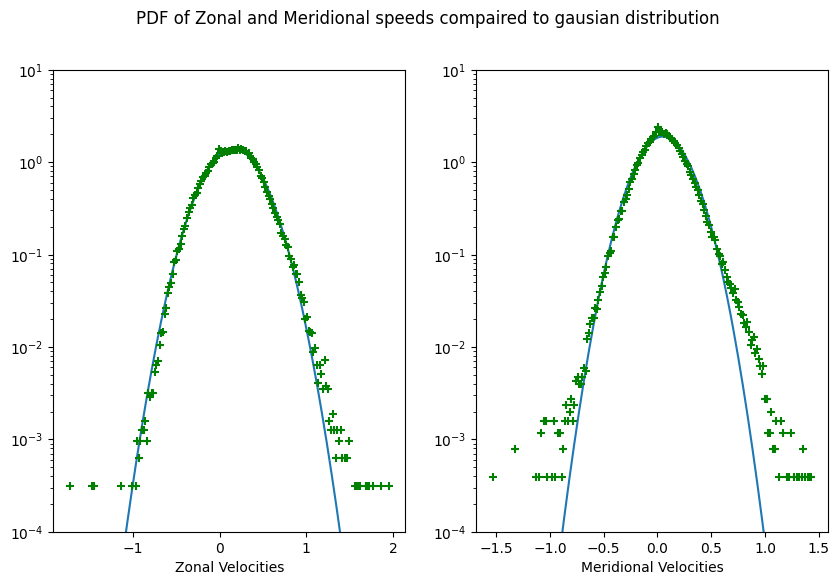

In [18]:
x_speeds = funcs.Column_to_List(ds, "x_speed")
y_speeds = funcs.Column_to_List(ds, "y_speed") 
# x_speeds = drift.ve.to_numpy(dtype = float)
# y_speeds = drift.vn.to_numpy(dtype = float)
print(len(x_speeds))
xmean = np.mean(x_speeds)
ymean = np.mean(y_speeds)
xvar = np.var(x_speeds)
yvar = np.var(y_speeds)
xrange = np.linspace(min(x_speeds), max(x_speeds), 200)
yrange = np.linspace(min(y_speeds), max(y_speeds), 200)
pdfx = norm.pdf(xrange, loc = xmean, scale = np.sqrt(xvar))
pdfy = norm.pdf(yrange, loc = ymean, scale = np.sqrt(yvar))
fig, ax = plt.subplots(1,2, figsize = (10,6))
counts, bins, patches = ax[0].hist(x_speeds, density= True, bins = 200, histtype='step', color = "White")
bin_centers = (bins[:-1] + bins[1:]) / 2
ax[0].scatter(bin_centers, counts, marker='+', color='g', zorder=10)
ax[0].plot(xrange,pdfx)
ax[0].set_xlabel("Zonal Velocities")
ax[1].set_xlabel("Meridional Velocities")
#ax[1].hist(y_speeds, density= True, bins = 200)
counts, bins, patches = ax[1].hist(y_speeds, density= True, bins = 200, histtype='step', color = "White")
bin_centers = (bins[:-1] + bins[1:]) / 2
ax[1].scatter(bin_centers, counts, marker='+', color='g', zorder=10)
ax[1].plot(yrange,pdfy)
ax[1].set_yscale("log")
ax[0].set_yscale("log")
ax[1].set_ylim(10e-5, 10)
ax[0].set_ylim(10e-5, 10)
fig.suptitle("PDF of Zonal and Meridional speeds compaired to gausian distribution")
fig.savefig(r"../Figures/PDF_of_dFADs_speeds.png")
